# Analysis of data for the Essential FFPE Panel

### Imports and basic setup

Import core scientific Python libraries (`numpy`, `pandas`, `matplotlib`) along with
utilities from `scikit-learn` and `scipy`. These will be used for clustering
evaluation (`cohen_kappa_score`), nearest-neighbor computations, and kernel
density estimation (`gaussian_kde`).


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import cohen_kappa_score
from sklearn.neighbors import NearestNeighbors
from scipy.stats import gaussian_kde
from sklearn.mixture import GaussianMixture


### BatchDetect module imports

Import project-specific helpers from the `batchdetect` package:

- `load_thal_cross_lot_covs` and related loaders for Thalassemia data.
- `HeavyMixture` and `parametric_bootstrap_lrt` for mixture modeling and
  parametric bootstrap-based likelihood ratio tests.
- Correlation-based clustering utilities:
  `cluster_hierarchical_corr`, `cluster_spectral_corr`,
  `cluster_pca_kmeans_corr`.
- Correlation preprocessing helpers: `normalize_mat` and `get_correlations`.

These functions implement the main batch-detection and clustering methods used
throughout the analysis.


In [2]:
from batchdetect.loader import *
from batchdetect.mixture import HeavyMixture,parametric_bootstrap_lrt

from batchdetect.clustering import cluster_hierarchical_corr,cluster_spectral_corr,cluster_pca_kmeans_corr
from batchdetect.sample_correlation import normalize_mat,get_correlations
from batchdetect.ward import pca_ward_clustering
from batchdetect.evaluation import accuracy_and_kappa_with_flip


### Helper functions: neighbor agreement, KDE plotting, and correlation utilities

Define several reusable helper functions:

- `neighbor_label_agreement`: for each sample, finds its k nearest neighbors
  in feature space and computes what fraction share the same label. This
  measures local label consistency under the chosen distance metric.
- `kde_by_label`: fits and plots one-dimensional kernel density estimates
  (KDEs) for a continuous variable, stratified by binary labels. This is used
  to visualize how well two groups are separated.
- `split_upper_tri_by_label`: given a correlation matrix and sample labels,
  extracts the upper-triangular correlations (excluding the diagonal) within
  each label group.
- `between_group_corr`: extracts the correlations between samples belonging
  to different label groups (0 vs 1 and 1 vs 0).
- `tv_distance_kde`: computes the total variation distance between two KDEs,
  providing a quantitative measure of how distinct the corresponding
  distributions are.

These utilities support both the correlation-based and likelihood-based
separability analyses later in the notebook.


In [3]:
def neighbor_label_agreement(X, y, k, metric="euclidean"):
    """
    For each row in X, find its k nearest neighbors (excluding itself),
    then compute the fraction of neighbors whose label matches y[i].

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Feature matrix.
    y : array-like, shape (n_samples,)
        Binary labels (0/1) corresponding to rows of X.
    k : int
        Number of neighbors to use (excluding self).
    metric : str, optional
        Distance metric for NearestNeighbors (default: "euclidean").

    Returns
    -------
    neighbor_indices : ndarray, shape (n_samples, k)
        Indices of the k nearest neighbors for each sample.
    match_percentages : ndarray, shape (n_samples,)
        For each sample i, the fraction of neighbors whose label
        matches y[i]. Values are between 0 and 1.
    """
    X = np.asarray(X)
    y = np.asarray(y).ravel()

    n_samples = X.shape[0]
    if k >= n_samples:
        raise ValueError("k must be less than the number of samples.")

    # We ask for k+1 neighbors so the closest one will be the point itself
    nn = NearestNeighbors(n_neighbors=k + 1, metric=metric)
    nn.fit(X)

    distances, indices = nn.kneighbors(X)

    # indices[:, 0] should be the sample itself; drop it
    neighbor_indices = indices[:, 1:]  # shape (n_samples, k)

    # Labels of neighbors
    neighbor_labels = y[neighbor_indices]  # shape (n_samples, k)

    # Compare neighbor labels to each sample's label
    sample_labels = y[:, np.newaxis]       # shape (n_samples, 1)
    matches = (neighbor_labels == sample_labels)  # boolean array

    # Fraction of matches per sample
    match_percentages = matches.mean(axis=1)

    return neighbor_indices, match_percentages


def split_upper_tri_by_label(corr, labels):
    """
    Given a correlation matrix and binary labels (0/1), extract the
    upper-triangular (no diagonal) entries for each label group after
    subsetting the matrix to that group.

    Parameters
    ----------
    corr : array-like, shape (n, n)
        Correlation matrix (assumed symmetric).
    labels : array-like, shape (n,)
        Vector of 0/1 labels corresponding to rows/cols of corr.

    Returns
    -------
    upper_0 : ndarray, shape (m0,), dtype=float
        Flattened upper-triangular entries (no diagonal) of the
        corr submatrix for label == 0. Empty if fewer than 2 samples.
    upper_1 : ndarray, shape (m1,), dtype=float
        Flattened upper-triangular entries (no diagonal) of the
        corr submatrix for label == 1. Empty if fewer than 2 samples.
    """
    corr = np.asarray(corr)
    labels = np.asarray(labels).ravel()

    if corr.shape[0] != corr.shape[1]:
        raise ValueError("corr must be a square matrix.")
    if corr.shape[0] != labels.shape[0]:
        raise ValueError("labels length must match corr dimension.")

    # Indices for each group
    idx0 = np.where(labels == 0)[0]
    idx1 = np.where(labels == 1)[0]

    # Helper to get flattened upper tri (k > i) for a submatrix
    def upper_tri_flat(sub):
        n = sub.shape[0]
        if n < 2:
            return np.array([], dtype=float)
        iu = np.triu_indices(n, k=1)
        return sub[iu]

    sub0 = corr[np.ix_(idx0, idx0)]
    sub1 = corr[np.ix_(idx1, idx1)]

    upper_0 = upper_tri_flat(sub0)
    upper_1 = upper_tri_flat(sub1)

    return upper_0, upper_1


def between_group_corr(corr, labels):
    """
    Extract all correlation values C[i,j] where labels differ:
    labels[i] != labels[j], using only i < j (upper triangle, no diagonal).

    Parameters
    ----------
    corr : array-like, shape (n, n)
        Symmetric correlation matrix.
    labels : array-like, shape (n,)
        Binary labels (0/1).

    Returns
    -------
    between_vals : ndarray
        Flattened array of correlations between groups.
    """
    corr = np.asarray(corr)
    labels = np.asarray(labels).ravel()

    if corr.shape[0] != corr.shape[1]:
        raise ValueError("corr must be a square matrix.")
    if corr.shape[0] != labels.shape[0]:
        raise ValueError("labels length must match corr dimension.")

    n = corr.shape[0]

    # Indices for the upper triangle (no diagonal)
    iu, ju = np.triu_indices(n, k=1)

    # Boolean mask for where labels differ
    mask = labels[iu] != labels[ju]

    # Extract only between-group correlations
    between_vals = corr[iu[mask], ju[mask]]

    return between_vals

def tv_distance_kde(kde1, kde2, num_points=2000, extend_frac=0.1):
    """
    Compute the total variation (TV) distance between two 1D KDEs.

    TV(p, q) = 0.5 * ∫ |p(x) - q(x)| dx

    Parameters
    ----------
    kde1 : scipy.stats.gaussian_kde
        First KDE object (1D).
    kde2 : scipy.stats.gaussian_kde
        Second KDE object (1D).
    num_points : int, optional
        Number of grid points for numerical integration.
    extend_frac : float, optional
        Fraction of the data range to extend below min and above max
        when constructing the common evaluation grid.

    Returns
    -------
    tv : float
        Total variation distance between the two KDEs, in [0, 1] in theory
        (but small numerical deviations are possible).
    """
    # Extract underlying sample data from the KDEs
    # gaussian_kde.dataset has shape (d, n). For 1D, d = 1.
    data1 = np.asarray(kde1.dataset).ravel()
    data2 = np.asarray(kde2.dataset).ravel()

    # Common range covering both distributions
    data_min = min(data1.min(), data2.min())
    data_max = max(data1.max(), data2.max())
    data_range = max(data_max - data_min, 1e-8)  # avoid zero range

    pad = extend_frac * data_range
    x_min = data_min - pad
    x_max = data_max + pad

    xs = np.linspace(x_min, x_max, num_points)

    # Evaluate both KDEs on the same grid
    p = kde1(xs)
    q = kde2(xs)

    # Numerical integration: ∫ |p - q| dx via trapezoidal rule
    abs_diff = np.abs(p - q)
    integral = np.trapz(abs_diff, xs)

    tv = 0.5 * integral
    return tv


def kde_by_label(
    x,
    y,
    xlabel="x",
    title="KDE by label",
    pastel_colors=("#a6cee3", "#b2df8a", "#fb9a99",
                   "#fdbf6f", "#cab2d6", "#ffffb3"),
    n_points=400,
    extend_frac=0.15,
):
    """
    Make a KDE plot of values x grouped by labels y, using pastel colors,
    common x-axis, and extended support so densities taper near 0.

    Parameters
    ----------
    x : array-like
        Vector of numeric values.
    y : array-like
        Vector of labels (binary or multi-class), same length as x.
    xlabel : str, optional
        X-axis label.
    title : str, optional
        Plot title.
    pastel_colors : tuple of str, optional
        Hex color codes for pastel colors.
    n_points : int, optional
        Number of evaluation points for KDE.
    extend_frac : float, optional
        Fraction of the data range to extend beyond min/max on each side.

    Returns
    -------
    None
        Displays a KDE plot for each group.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    if x.shape[0] != y.shape[0]:
        raise ValueError("x and y must have the same length.")

    groups = np.unique(y)

    # Common support for all densities
    data_min = np.min(x)
    data_max = np.max(x)
    data_range = data_max - data_min if data_max > data_min else 1.0
    pad = extend_frac * data_range

    xs = np.linspace(data_min - pad, data_max + pad, n_points)

    plt.figure(figsize=(6, 5))

    for i, g in enumerate(groups):
        vals = x[y == g]
        if vals.size == 0:
            continue

        kde = gaussian_kde(vals)
        color = pastel_colors[i % len(pastel_colors)]
        plt.plot(xs, kde(xs), label=f"Group {g+1}", linewidth=2.5, color=color)

    plt.xlabel(xlabel, fontsize=20)
    plt.title(title, fontsize=24)
    plt.legend(frameon=False,fontsize=16)

    # No grid
    plt.grid(False)

    # Spine styling: only left & bottom, thicker
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2.5)
    ax.spines["bottom"].set_linewidth(2.5)
    ax.tick_params(axis="both", which="both", labelsize=11)

    plt.tight_layout()


### Load Thalassemia likelihood results

Read the Thalassemia likelihood summary file (`likelihoods_thal131.csv`)
into a pandas DataFrame. This file contains sample-level log likelihoods
and associated metadata (e.g., sample names and labels) used to evaluate
clustering performance.


In [4]:
df_thal_likelihoods = pd.read_csv('likelihoods_essential.csv')
print(df_thal_likelihoods.head())
snames = df_thal_likelihoods['Sample Name'].values
likelihoods = df_thal_likelihoods['Likelihood'].values
y_hat = df_thal_likelihoods['Label'].values

                                         Sample Name  Likelihood  Label
0  RDvSMpEssentialLBxd250509iN4-06A_PC2504014T1_20ng  -45.592543      0
1  RDvSMpEssentialLBxd250509iN4-06A_PC2504014T1_40ng  -28.952638      0
2  RDvSMpEssentialLBxd250509iN4-06B_PC2504014T15_...  -23.703107      0
3  RDvSMpEssentialLBxd250509iN4-06C_PC2504014T30_...  -27.889823      0
4  RDvSMpEssentialLBxd250509iN4-06D_PC2504015T1_20ng -114.047653      0


### Load  count data and metadata

Load the cross-lot coverage
matrix and associated metadata:

- `counts_thal`: amplicon-level coverage counts per sample.
- `y_thal`: sample labels from the loader (if provided).
- `sample_id`: sample identifiers.
- `features`: amplicon/feature annotations.

These raw counts are used for correlation-based clustering and neighborhood
analysis.


In [5]:
counts_thal,y_thal,sample_id,features,_ = load_essential_ffpe()
counts_thal = counts_thal[:-1]
y_thal = y_thal[:-1]
sample_id = sample_id[:-1]

In [6]:
index_homozygous_del = []
counts_thal_new = np.delete(counts_thal, index_homozygous_del, axis=0)
likelihoods_new = np.delete(likelihoods, index_homozygous_del)
y_new = np.delete(y_hat, index_homozygous_del)
snames_new = np.delete(snames,index_homozygous_del)

### Fit mixture model to likelihoods

Instantiate a two-component `HeavyMixture` model using a generalized
normal (`gennorm`) component distribution, and fit it to the filtered
likelihoods (`likelihoods_new`). The fitted model is then used to generate
cluster assignments (`labels_likelihood`) for each sample based solely
on the likelihood values.


In [7]:
model = HeavyMixture(2,component_distribution='gennorm',random_state=2021)
model.fit(likelihoods_new)
labels_likelihood = model.predict(likelihoods_new)

### Compute accuracy and Cohen’s kappa for our method

Compare the mixture-model-derived labels (`labels_likelihood`) against the
filtered reference labels (`y_new`):

- `acc_ours`: overall classification accuracy.
- `kappa_ours`: Cohen’s kappa, which adjusts for chance agreement.

This quantifies how well the likelihood-based mixture model recovers the
reference call set.

Note that we have "cheated", and flipped the sign of the labels. Given that we do that for the remaining methods, it's still a fair comparison.

In [8]:
acc_ours,kappa_ours,used_flip_ours = accuracy_and_kappa_with_flip(labels_likelihood,y_new)

### Correlation-based clustering from normalized counts

Normalize the Thalassemia coverage matrix and compute a sample–sample
correlation matrix:

- `counts_norm`: normalized coverage matrix.
- `corr_new`: correlation matrix across samples.

Apply three correlation-based clustering methods with two clusters:

- `labels_hier`: hierarchical clustering.
- `labels_spec`: spectral clustering on the correlation graph.
- `labels_kmean`: PCA followed by K-means on correlation-derived features.

These provide alternative clusterings to compare against the likelihood-based
approach.


In [9]:
counts_norm = normalize_mat(counts_thal_new)
corr_new,_ = get_correlations(counts_norm)

labels_hier = cluster_hierarchical_corr(corr_new,2)
labels_spec = cluster_spectral_corr(corr_new,2)
labels_kmean = cluster_pca_kmeans_corr(corr_new,2,2)

### Evaluate correlation-based clustering performance

Re-use the correlation-based cluster assignments (`labels_hier`,
`labels_spec`, `labels_kmean`) and compare them to the filtered reference
labels (`y_new`):

- `acc_hier`, `acc_spec`, `acc_kmean`: classification accuracy for the
  hierarchical, spectral, and PCA–K-means methods, respectively.
- `kappa_hier`, `kappa_spec`, `kappa_kmean`: corresponding Cohen’s kappa
  scores for each method.

This allows a direct performance comparison between correlation-based
clustering methods and the likelihood mixture model.


In [10]:
labels_hier = cluster_hierarchical_corr(corr_new,2)
labels_spec = cluster_spectral_corr(corr_new,2)
labels_kmean = cluster_pca_kmeans_corr(corr_new,2,2)

acc_hier,kappa_hier,used_flip_hier = accuracy_and_kappa_with_flip(labels_hier,y_new)
acc_spec,kappa_spec,used_flip_spec = accuracy_and_kappa_with_flip(labels_spec,y_new)
acc_kmean,kappa_kmean,used_flip_kmean = accuracy_and_kappa_with_flip(labels_kmean,y_new)


In [11]:
model_gmm = GaussianMixture(2,random_state=2022).fit(counts_norm)
labels_gmm = model_gmm.predict(counts_norm)
acc_gmm,kappa_gmm,used_flip_gmm = accuracy_and_kappa_with_flip(labels_gmm,y_new)

labels_ward = pca_ward_clustering(counts_norm)
acc_ward,kappa_ward,used_flip_ward = accuracy_and_kappa_with_flip(labels_ward,y_new)

In [12]:
print('Our method accuracy: ',acc_ours)
print('Hierarchical method accuracy: ',acc_hier)
print('Spectral method accuracy: ',acc_spec)
print('Kmean PCA method accuracy: ',acc_kmean)
print('GMM method accuracy: ',acc_gmm)
print('Ward method accuracy: ',acc_ward)


Our method accuracy:  1.0
Hierarchical method accuracy:  0.71875
Spectral method accuracy:  0.9375
Kmean PCA method accuracy:  0.9375
GMM method accuracy:  0.90625
Ward method accuracy:  0.90625


In [13]:
print('Our method kappa: ',kappa_ours)
print('Hierarchical method kappa: ',kappa_hier)
print('Spectral method kappa: ',kappa_spec)
print('Kmean PCA method kappa: ',kappa_kmean)
print('GMM method kappa: ',kappa_gmm)
print('Ward method kappa: ',kappa_ward)


Our method kappa:  1.0
Hierarchical method kappa:  0.13253012048192772
Spectral method kappa:  0.8461538461538461
Kmean PCA method kappa:  0.8545454545454545
GMM method kappa:  0.7623762376237624
Ward method kappa:  0.7623762376237624


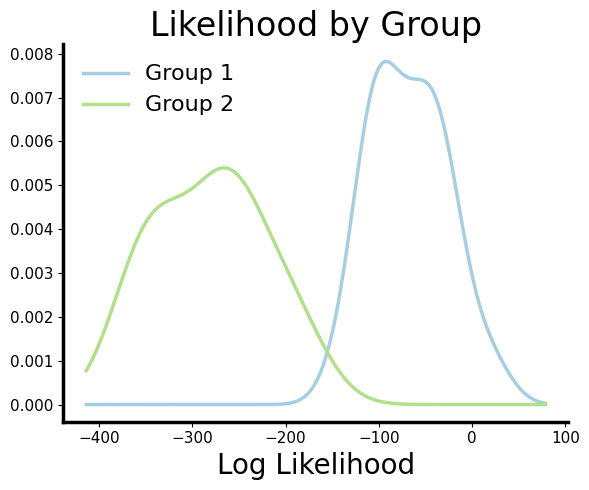

In [14]:
kde_by_label(likelihoods_new,y_new,
             title='Likelihood by Group',xlabel='Log Likelihood')

In [15]:
upper0,upper1 = split_upper_tri_by_label(corr_new,y_new)
homogeneous_comb = np.concatenate((upper0,upper1))
heterogeneous = between_group_corr(corr_new,y_new)

In [16]:
corr_groupings = np.concatenate((homogeneous_comb,heterogeneous))
corr_labels = np.zeros(len(corr_groupings))
corr_labels[len(homogeneous_comb):] = 1


In [17]:
kde_homo = gaussian_kde(homogeneous_comb)
kde_hetero = gaussian_kde(heterogeneous)
tv_corr = tv_distance_kde(kde_homo,kde_hetero)
print(tv_corr)

0.7057045542735125


/var/folders/k4/8f7w5xpd05v9x_bwsy54mh8r0000gn/T/ipykernel_41874/4086926208.py:189: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(abs_diff, xs)


In [18]:
kde_g1 = gaussian_kde(likelihoods_new[y_new==0])
kde_g2 = gaussian_kde(likelihoods_new[y_new==1])
tv_like = tv_distance_kde(kde_g1,kde_g2)
print(tv_like)

0.9380514528034076


/var/folders/k4/8f7w5xpd05v9x_bwsy54mh8r0000gn/T/ipykernel_41874/4086926208.py:189: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(abs_diff, xs)


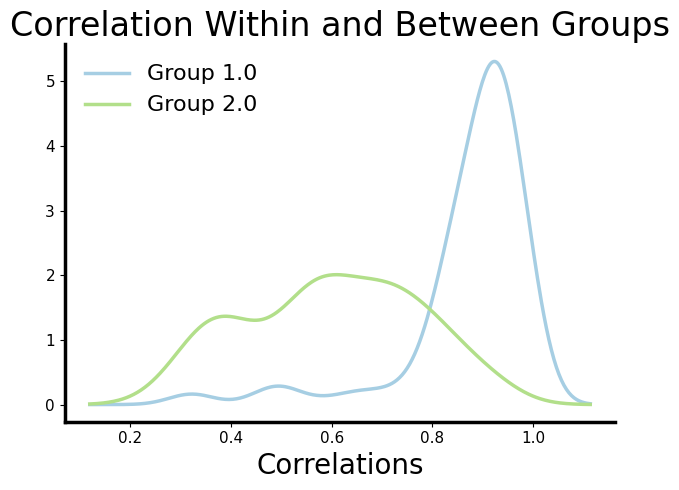

In [19]:
kde_by_label(corr_groupings,corr_labels,
             title='Correlation Within and Between Groups',
             xlabel='Correlations')